In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

# Exercise 1 - SCM at L1

In [10]:
def SCM():
    
    U_smoking = np.random.binomial(n=1,p=.5)
    U_environment = np.random.binomial(n=1,p=.3)
    U_tar = np.random.binomial(n=1,p=.1)
    U_cancer = np.random.normal()
    U_cough = np.random.binomial(n=1,p=.4)
    
    environment = U_environment
    smoking = (U_smoking + environment) > 1
    tar = (smoking-U_tar) >= 1
    cancer = (tar/2 + environment + U_cancer/2) > 1.5
    cough = (smoking + cancer + U_cough) / 2
    
    return [environment,smoking,tar,cancer,cough]

## 1. Collect a sample

In [11]:
SCM()

[0, False, False, False, 0.5]

## 2. Collect a dataset

In [12]:
D = []
for _ in range(1000):
    D.append(SCM())

In [13]:
df = pd.DataFrame(D,columns=['E','S','T','LC','C'])
df.head()

,E,S,T,LC,C
0,0,False,False,False,0.0
1,0,False,False,False,0.5
2,0,False,False,False,0.0
3,0,False,False,False,0.5
4,0,False,False,False,0.5


## 3. Compute quantities

### P(T,LC)

In [14]:
pd.crosstab(df['T'], df['LC'], normalize=True)

LC,False,True
T,,
False,0.837,0.025
True,0.070,0.068


<Axes: xlabel='LC', ylabel='T'>

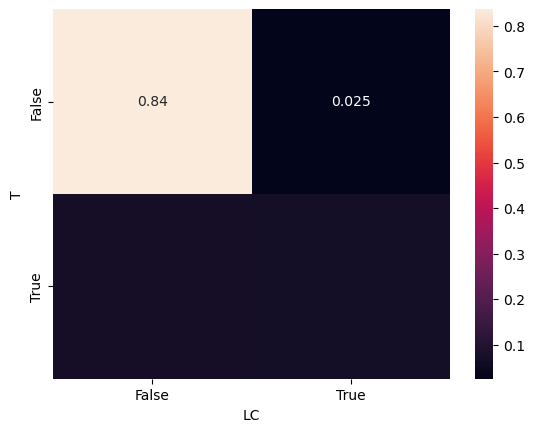

In [15]:
sns.heatmap(pd.crosstab(df['T'], df['LC'], normalize=True), annot=True)

### P(LC | S)

In [16]:
pd.crosstab(df['S'], df['LC'], normalize='index')

LC,False,True
S,,
False,0.970449,0.029551
True,0.558442,0.441558


<Axes: xlabel='S'>

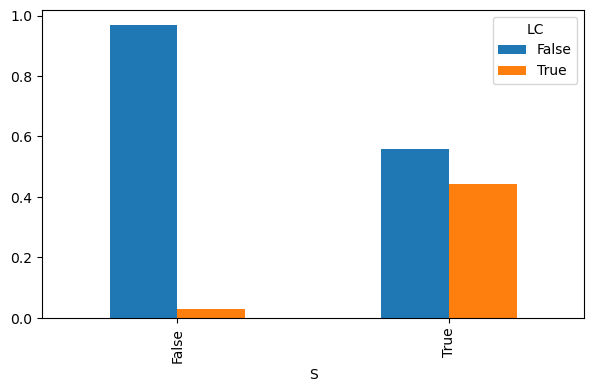

In [17]:
pd.crosstab(df['S'], df['LC'], normalize='index').plot(kind='bar', figsize=(7, 4))

# Exercise 2 - SCM at L2

In [18]:
def SCM_do():
    
    U_smoking = np.random.binomial(n=1,p=.5)
    U_environment = np.random.binomial(n=1,p=.3)
    U_tar = np.random.binomial(n=1,p=.1)
    U_cancer = np.random.normal()
    U_cough = np.random.binomial(n=1,p=.4)
    
    environment = U_environment
    smoking = 1
    tar = (smoking-U_tar) >= 1
    cancer = (tar/2 + environment + U_cancer/2) > 1.5
    cough = (smoking + cancer + U_cough) / 2
    
    return [environment,smoking,tar,cancer,cough]

## 1. Collect a sample

In [19]:
SCM_do()

[0, 1, True, False, 0.5]

## 2. Collect a dataset

In [20]:
D = []
for _ in range(1000):
    D.append(SCM_do())

In [21]:
df = pd.DataFrame(D,columns=['E','S','T','LC','C'])
df.head()

,E,S,T,LC,C
0,0,1,True,False,1.0
1,0,1,True,False,0.5
2,0,1,True,False,1.0
3,0,1,True,False,0.5
4,1,1,True,True,1.5


## 3. Compute quantities

### P(T,LC)

In [22]:
pd.crosstab(df['T'], df['LC'], normalize=True)

LC,False,True
T,,
False,0.089,0.007
True,0.745,0.159


<Axes: xlabel='LC', ylabel='T'>

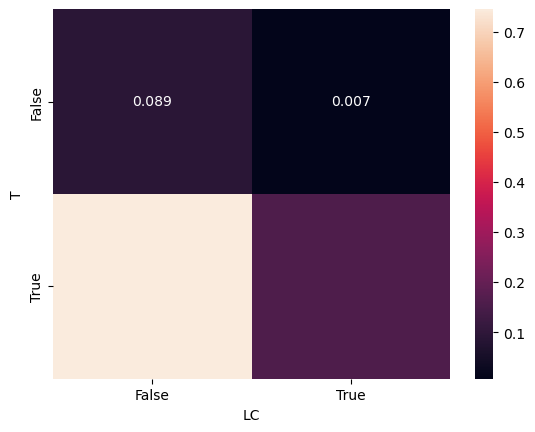

In [23]:
sns.heatmap(pd.crosstab(df['T'], df['LC'], normalize=True), annot=True)

### P(LC | S)

In [24]:
pd.crosstab(df['S'], df['LC'], normalize='index')

LC,False,True
S,,
1,0.834,0.166


<Axes: xlabel='S'>

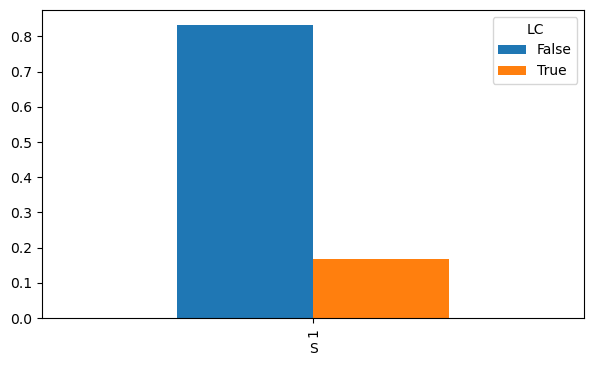

In [25]:
pd.crosstab(df['S'], df['LC'], normalize='index').plot(kind='bar', figsize=(7, 4))

# Exercise 3 - SCM at L3

In [26]:
def SCM_do():
    
    U_smoking = np.random.binomial(n=1,p=.5)
    U_environment = np.random.binomial(n=1,p=.3)
    U_tar = np.random.binomial(n=1,p=.1)
    U_cancer = np.random.normal()
    U_cough = np.random.binomial(n=1,p=.4)
    
    environment = U_environment
    smoking = 1
    tar = (smoking-U_tar) >= 1
    cancer = (tar/2 + environment + U_cancer/2) > 1.5
    cough = (smoking + cancer + U_cough) / 2
    
    return [U_smoking,U_environment,U_tar,U_cancer,U_cough,environment,smoking,tar,cancer,cough]

In [27]:
def SCM_ctf(U_smoking,U_environment,U_tar,U_cancer,U_cough):
    
    environment = U_environment
    smoking = 0
    tar = (smoking-U_tar) >= 1
    cancer = (tar/2 + environment + U_cancer/2) > 1.5
    cough = (smoking + cancer + U_cough) / 2
    
    return [environment,smoking,tar,cancer,cough]

## 1. Collect a sample

In [21]:
actual_sample = SCM_do()
ctf_sample = SCM_ctf(actual_sample[0],actual_sample[1],actual_sample[2],actual_sample[3],actual_sample[4])

## 2. Collect a dataset

In [30]:
D = []
for _ in range(1000):
    actual_sample = SCM_do()
    ctf_sample = SCM_ctf(actual_sample[0],actual_sample[1],actual_sample[2],actual_sample[3],actual_sample[4])
    D.append(ctf_sample)

In [31]:
df = pd.DataFrame(D,columns=['E','S','T','LC','C'])
df.head()

,E,S,T,LC,C
0,0,0,False,False,0.0
1,1,0,False,False,0.0
2,1,0,False,False,0.5
3,1,0,False,False,0.0
4,1,0,False,False,0.0


## 3. Compute quantities

### P(T,LC)

In [32]:
pd.crosstab(df['T'], df['LC'], normalize=True)

LC,False,True
T,,
False,0.947,0.053


<Axes: xlabel='LC', ylabel='T'>

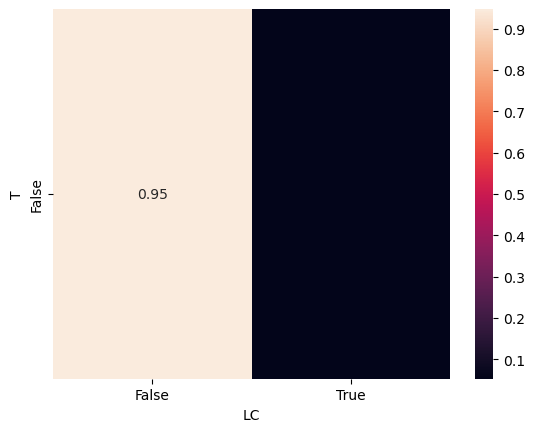

In [33]:
sns.heatmap(pd.crosstab(df['T'], df['LC'], normalize=True), annot=True)

### P(LC | S)

In [35]:
pd.crosstab(df['S'], df['LC'], normalize='index')

LC,False,True
S,,
0,0.947,0.053


<Axes: xlabel='S'>

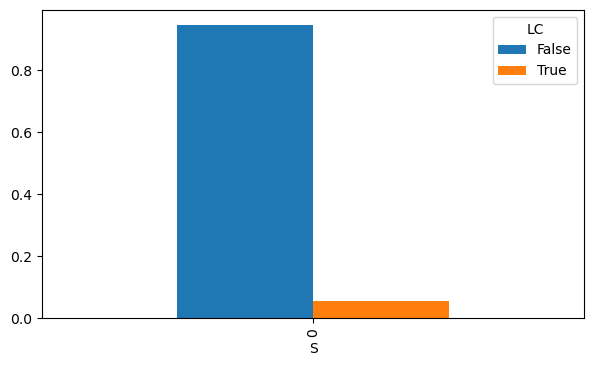

In [36]:
pd.crosstab(df['S'], df['LC'], normalize='index').plot(kind='bar', figsize=(7, 4))